In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

In [3]:
df = pd.read_csv('/content/FraudDataset.csv')
# dataset link - https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset/data

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            138116 non-null  int64  
 1   type            138116 non-null  object 
 2   amount          138116 non-null  float64
 3   nameOrig        138116 non-null  object 
 4   oldbalanceOrg   138116 non-null  float64
 5   newbalanceOrig  138116 non-null  float64
 6   nameDest        138116 non-null  object 
 7   oldbalanceDest  138115 non-null  float64
 8   newbalanceDest  138115 non-null  float64
 9   isFraud         138115 non-null  float64
 10  isFlaggedFraud  138115 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 11.6+ MB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df['isFraud'].value_counts()

,count
isFraud,
0.0,137993
1.0,122


In [8]:
df['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0.0,138115


In [9]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [10]:
df.shape

(138116, 11)

In [11]:
round((df['isFraud'].value_counts()[1] / df.shape[0])*100,2)

np.float64(0.09)

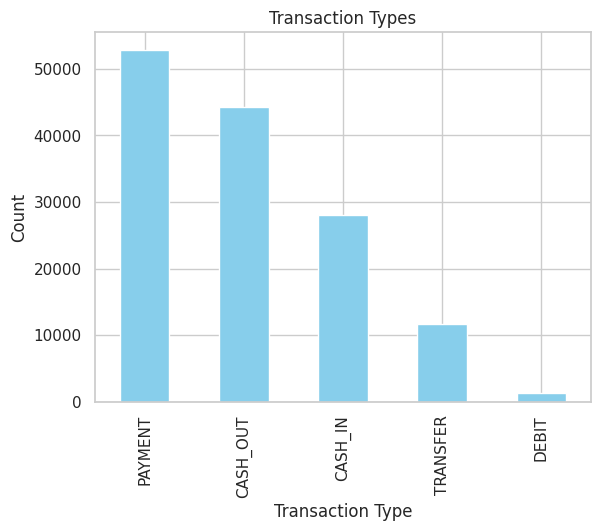

In [12]:
df['type'].value_counts().plot(kind="bar", title="Transaction Types",color="skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

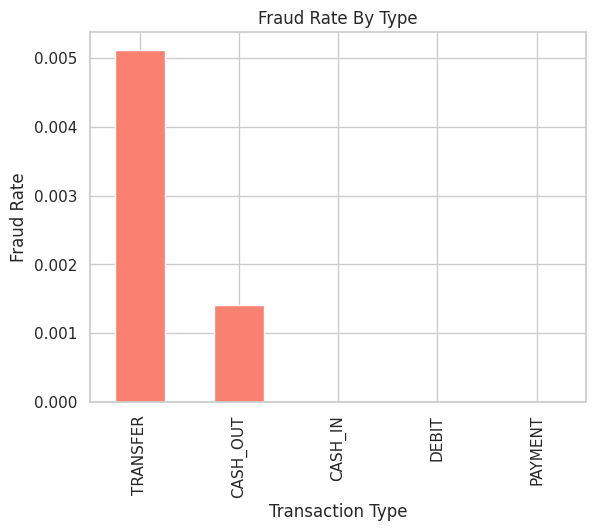

In [13]:
fraud_by_type = df.groupby("type")['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar",title="Fraud Rate By Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")
plt.show()

In [14]:
df['amount'].describe().astype(int)

,amount
count,138116
mean,178427
std,341749
min,0
25%,10889
50%,60071
75%,221085
max,10000000


Text(0, 0.5, 'Count')

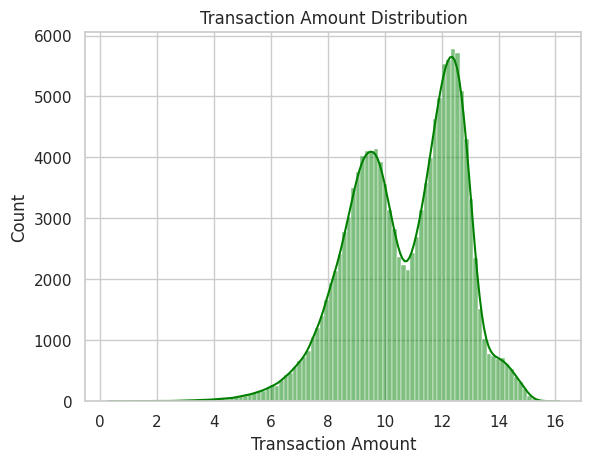

In [15]:
sns.histplot(np.log1p(df['amount']), bins=100,kde=True, color="green")
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")

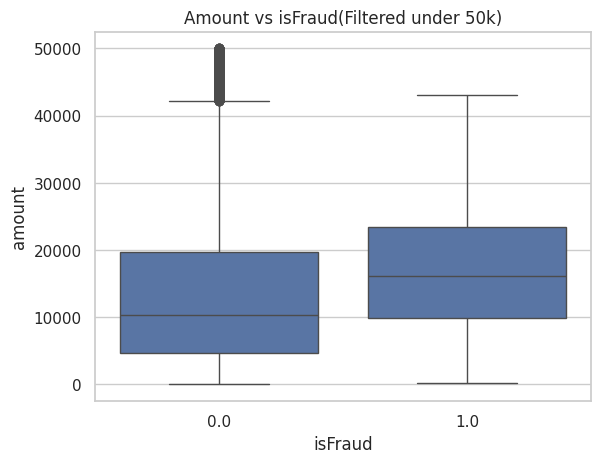

In [16]:
sns.boxplot(data=df[df["amount"]<50000], x="isFraud", y="amount")
plt.title("Amount vs isFraud(Filtered under 50k)")
plt.show()

In [17]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['oldbalanceDest'] - df['newbalanceDest']

In [18]:
(df['balanceDiffOrig'] < 0).sum()

np.int64(27972)

In [19]:
(df['balanceDiffDest'] < 0).sum()

np.int64(57266)

In [20]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0


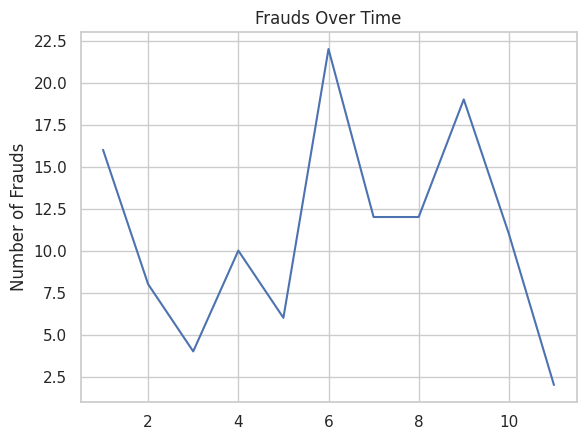

In [21]:
frauds_per_step = df[df['isFraud']==1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Fraud per Step")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [22]:
df.drop(columns="step",inplace=True)

In [23]:
top_senders = df["nameOrig"].value_counts().head(10)

In [24]:
top_senders

,count
nameOrig,
C1709295811,2
C735807111,1
C682200934,1
C1144414057,1
C1874807440,1
C1056069331,1
C1522810068,1
C754974194,1
C964811063,1


In [25]:
top_receivers = df["nameDest"].value_counts().head(10)

In [26]:
top_receivers

,count
nameDest,
C985934102,80
C1286084959,77
C248609774,73
C1590550415,72
C2083562754,69
C977993101,67
C665576141,67
C1360767589,63
C451111351,62


In [27]:
fraud_users = df[df['isFraud']==1]['nameOrig'].value_counts()

In [28]:
fraud_users

,count
nameOrig,
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C137533655,1
...,...
C813115168,1
C184586799,1
C1105700111,1


In [29]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [30]:
fraud_types["type"].value_counts()

,count
type,
CASH_OUT,44256
TRANSFER,11712


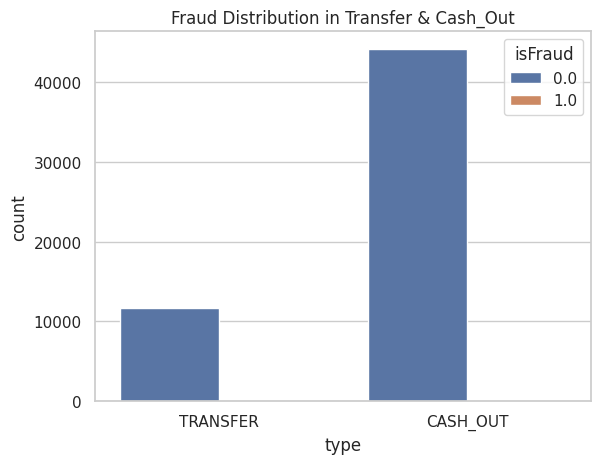

In [31]:
sns.countplot(data=fraud_types, x='type', hue='isFraud')
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

In [32]:
corr = df[['amount', 'oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']].corr()

In [33]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.016798,-0.022207,0.234142,0.361064,0.033093
oldbalanceOrg,-0.016798,1.000000,0.998972,0.097134,0.066367,-0.003436
newbalanceOrig,-0.022207,0.998972,1.000000,0.098629,0.065312,-0.009190
oldbalanceDest,0.234142,0.097134,0.098629,1.000000,0.945485,-0.008594
newbalanceDest,0.361064,0.066367,0.065312,0.945485,1.000000,-0.005799
isFraud,0.033093,-0.003436,-0.009190,-0.008594,-0.005799,1.000000


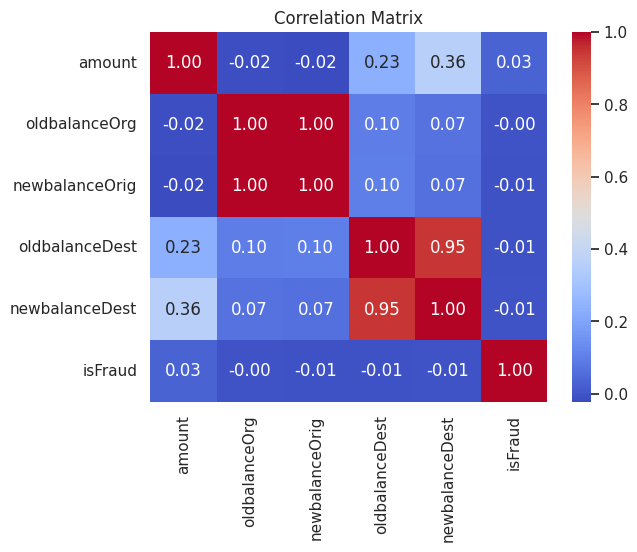

In [34]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [35]:
zero_after_transfer = df[
    (df['oldbalanceOrg']>0) &
    (df['newbalanceOrig']==0) &
    (df['type'].isin(["TRANSFER","CASH_OUT"]))
]

In [36]:
len(zero_after_transfer)

21921

In [37]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1.0,0.0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1.0,0.0,181.0,21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0.0,0.0,15325.0,-46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0.0,0.0,705.0,22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0.0,0.0,10835.0,-2712905.89


In [38]:
df['isFraud'].value_counts()

,count
isFraud,
0.0,137993
1.0,122


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [40]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [41]:
df_model = df.drop(['nameOrig','nameDest','isFlaggedFraud'], axis=1)

In [42]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,181.00,21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0.0


In [52]:
df_model = df_model.dropna(subset=['isFraud'])

In [53]:
from numpy._core import numeric
categorical = ['type']
numeric = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

In [54]:
X = df_model.drop('isFraud', axis=1)
y = df_model['isFraud']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y)

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(), categorical)
    ],
    remainder="drop"
)

In [58]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",LogisticRegression(class_weight="balanced",max_iter=1000))
])

In [59]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat', OneHotEncoder(),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [60]:
y_pred = pipeline.predict(X_test);

In [61]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n         0.0       1.00      0.85      0.92     41398\n         1.0       0.01      0.97      0.01        37\n\n    accuracy                           0.85     41435\n   macro avg       0.50      0.91      0.47     41435\nweighted avg       1.00      0.85      0.92     41435\n'

In [65]:
confusion_matrix(y_test,y_pred)

array([[35296,  6102],
       [    1,    36]])

In [68]:
# accuracy = pipeline.score(X_test, y_test)
# print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8527


In [71]:
pipeline.score(X_test,y_test)

0.852709062386871

In [72]:
import joblib

joblib.dump(pipeline, 'fraud_detection_model.pkl')

['fraud_detection_model.pkl']